In [16]:
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
import joblib
from scipy.ndimage import uniform_filter1d
import utils.ovo_svm as ovo_svm
sys.modules["ovo_svm"] = ovo_svm
from utils.ovo_svm import OvO_SVM
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from utils.Hog import HoG, calc_gradients, predict_char
from utils.MSER import merge_boxes, filter_char_boxes, merge_char_words, get_word_boxes, sort_boxes_reading_order, sort_word_chars
from utils.text_detector import extract_word_images

In [17]:
model = OvO_SVM().load("./models/from_scratch_SVM")
le = joblib.load("./models/from_scratch_SVM/OvO_SVM_label_encoder.joblib")


f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [18]:
img = cv2.imread("./images/ocr.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

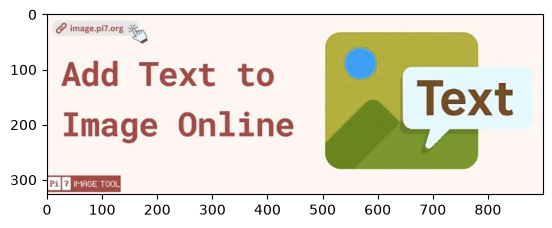

In [19]:
plt.imshow(img)

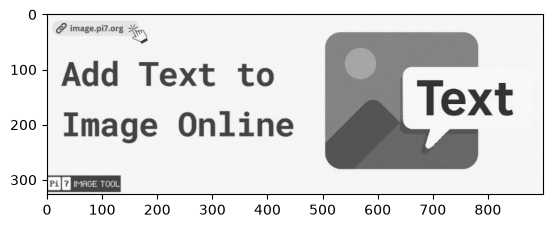

In [20]:
plt.imshow(gray, cmap='gray')

In [21]:
mser = cv2.MSER_create()
# mser.setMinArea()

Number of regions: 793
Number of boxes: 793
Number of unique boxes: 52


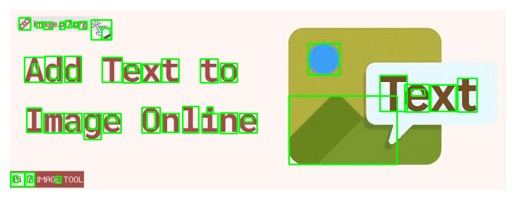

In [22]:
plt.axis('off')

regions, boxes = mser.detectRegions(gray)
unique_boxes = set(tuple(b) for b in boxes)
unique_boxes = [list(b) for b in unique_boxes]
unique_boxes = merge_boxes(unique_boxes, threshold=0.3)
unique_boxes = filter_char_boxes(unique_boxes, lower_bound=0.1, higher_bound=2.5)

print(f"Number of regions: {len(regions)}")
print(f"Number of boxes: {len(boxes)}")
print(f"Number of unique boxes: {len(unique_boxes)}")

img_copy = img.copy()
for i in range(len(unique_boxes)):
    x, y, w, h = unique_boxes[i]
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(img_copy)
plt.show()
box_0 = unique_boxes[0]
char_0 = gray[box_0[1]:box_0[1]+box_0[3], box_0[0]:box_0[0]+box_0[2]]


In [23]:
words = merge_char_words(unique_boxes, x_thresh=10, y_thresh=20)
print(f"Number of words: {len(words)}")

Number of words: 26


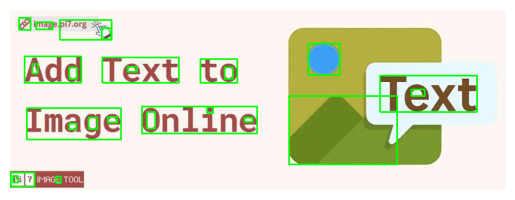

26


In [24]:
word_boxes = get_word_boxes(words)

img_copy = img.copy()

for (x, y, w, h) in word_boxes:
    cv2.rectangle(
        img_copy,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.imshow(img_copy)
plt.axis("off")
plt.show()
print(len(words))

In [25]:
char_non_char_model = joblib.load("./models/is_char_svm_model.joblib")

f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Number of words: 10


[0.040115419715166384, 0.03748206775719578, 0.03670248519725425]
1.0702563149671767
Predicted label for test image: a


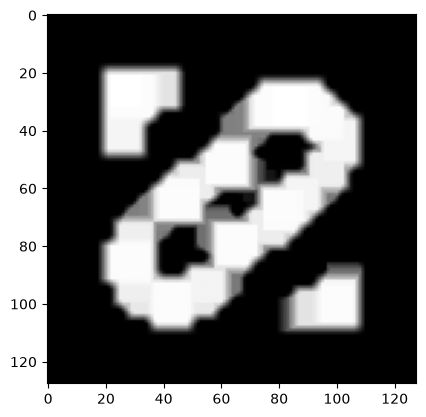

[0.041855557837251846, 0.04155258260870963, 0.03839663753877771]
1.007291369381183
Predicted label for test image: M


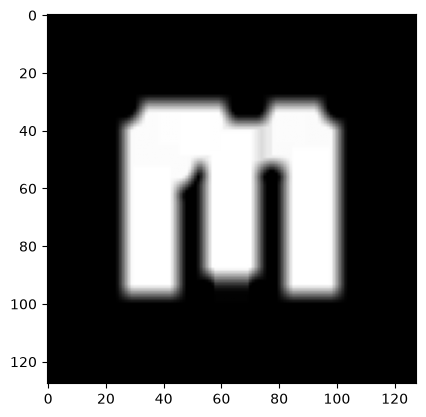

[0.039807464394440197, 0.03933492419818776, 0.03818987238019443]
1.0120132479186068
Predicted label for test image: M


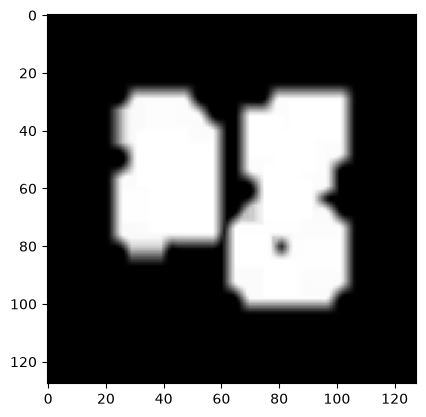

[0.04048955359593277, 0.03950980654251137, 0.037740168025381285]
1.0247975664565006
Predicted label for test image: P


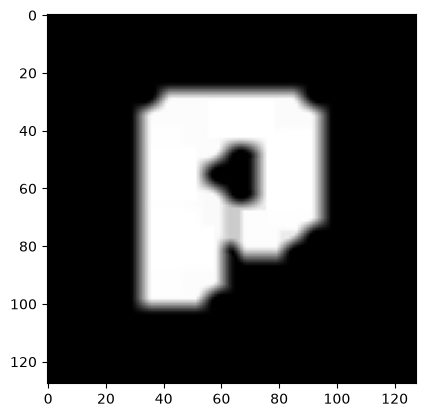

[0.038360197985494934, 0.03719782079773721, 0.036877975039616435]
1.031248529156537
Predicted label for test image: n


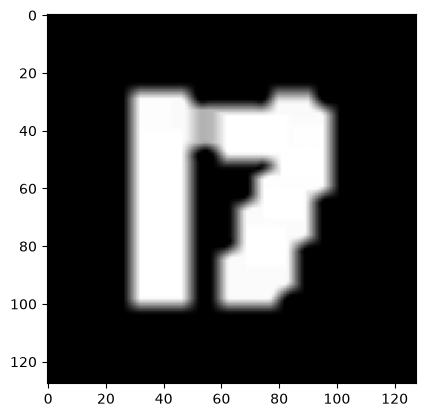

[0.03944319755875294, 0.039187423245991754, 0.038620583047208897]
1.0065269489947224
Predicted label for test image: D


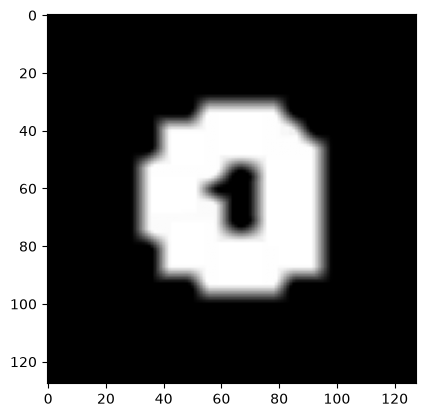

[0.039951393189456376, 0.03937334595313387, 0.03866265160351482]
1.0146811814523093
Predicted label for test image: n


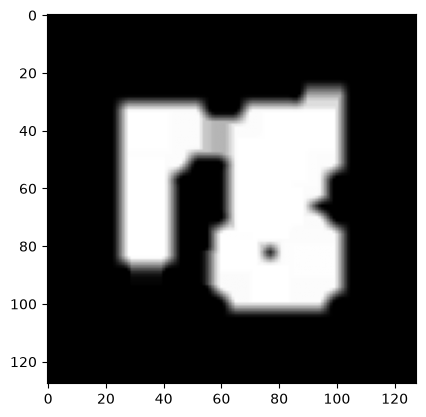

[0.03904722471627833, 0.03839805915753263, 0.03698831139626763]
1.0169062075789408
Predicted label for test image: H


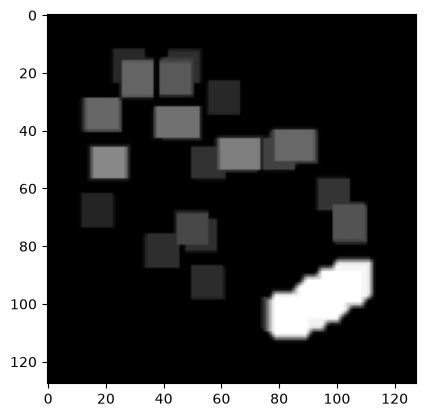

[0.03946036648302864, 0.037788520524884725, 0.03738211044073562]
1.0442421649464408
Predicted label for test image: D


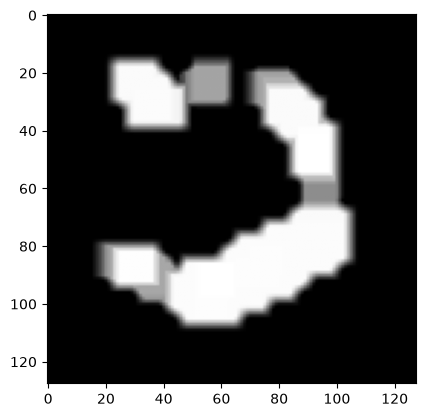

[0.036844775771308035, 0.03458122302940056, 0.03435227062204133]
1.0654561216641478
Predicted label for test image: U


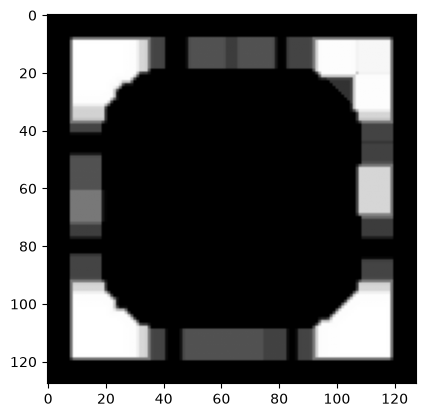

[0.04113435400798933, 0.03797015699857287, 0.03564692972394798]
1.0833337878886145
Predicted label for test image: A


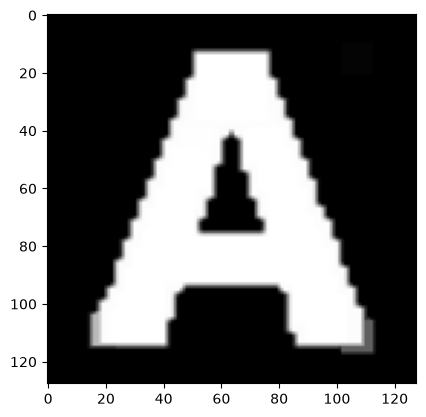

[0.039879153514352186, 0.03917239329987274, 0.037747432932688924]
1.018042303646577
Predicted label for test image: U


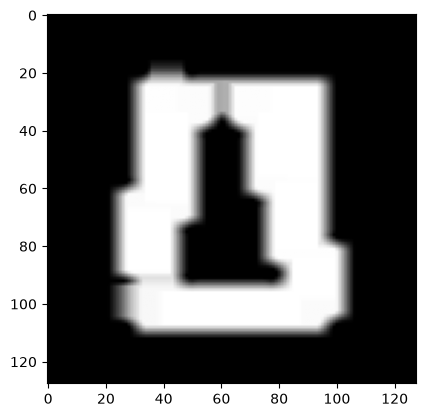

[0.04200588747421547, 0.040596477906249095, 0.03844837034949041]
1.0347175331618959
Predicted label for test image: d


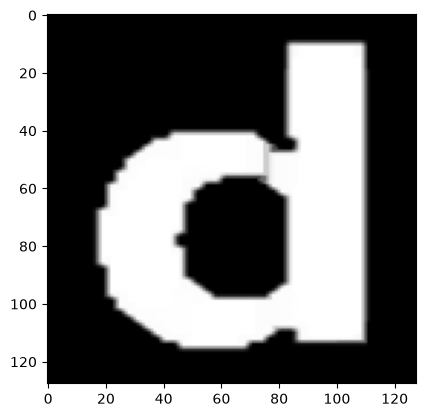

[0.04075719756883172, 0.039823543224843924, 0.0369768154019654]
1.0234447833713936
Predicted label for test image: U


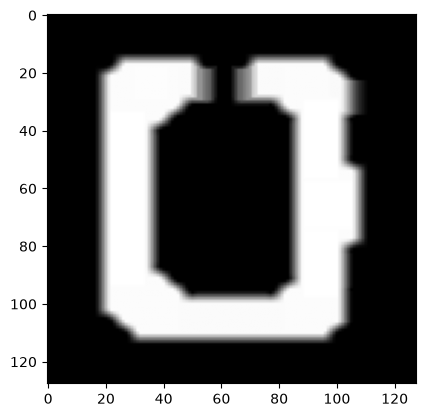

[0.0419467460023781, 0.04057144495225535, 0.0383993863665498]
1.0338982516334139
Predicted label for test image: d


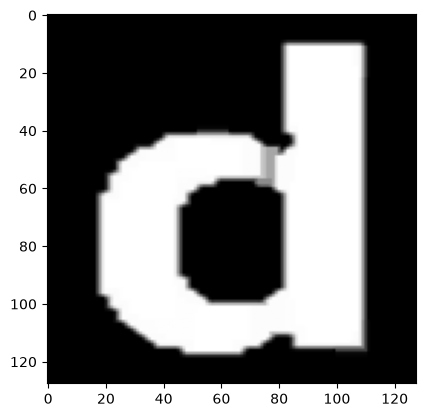

[0.04123847278001483, 0.0403061122490972, 0.037029375103763695]
1.0231319886461765
Predicted label for test image: U


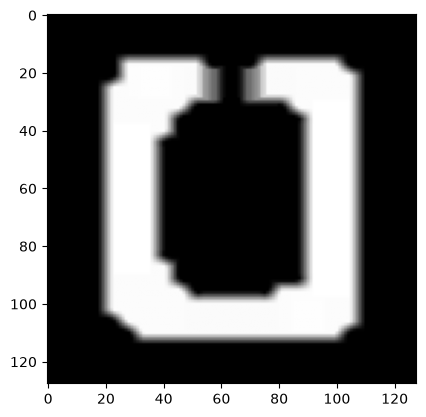

[0.04239186482424916, 0.04034499138628005, 0.03911271391371849]
1.0507342638488004
Predicted label for test image: T


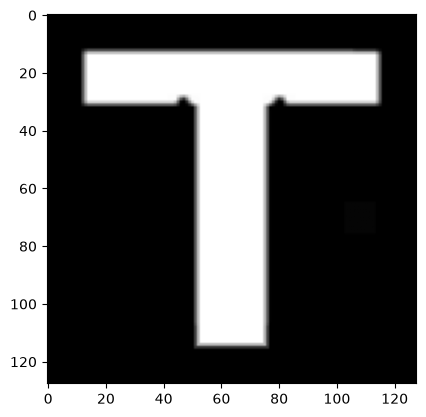

[0.042292183827838656, 0.039795769091299144, 0.03862590509416129]
1.0627306568899888
Predicted label for test image: e


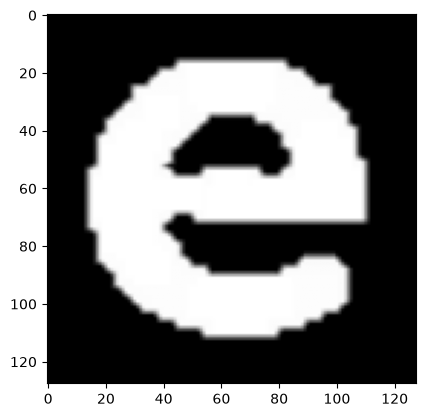

[0.04060485068267027, 0.040177631275399965, 0.03974169023014861]
1.0106332651704106
Predicted label for test image: a


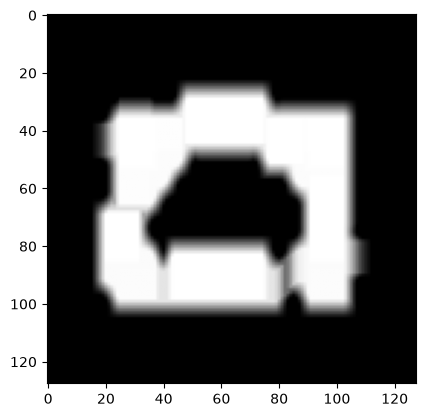

[0.04224136480606461, 0.038774935270220905, 0.03847830055073219]
1.0893987188292205
Predicted label for test image: X


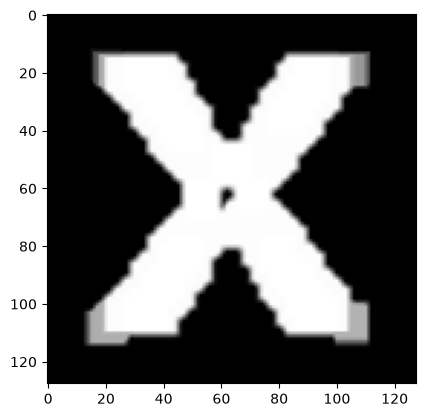

[0.04151628361890183, 0.03610856613339932, 0.035962729122066654]
1.1497627312456622
Predicted label for test image: t


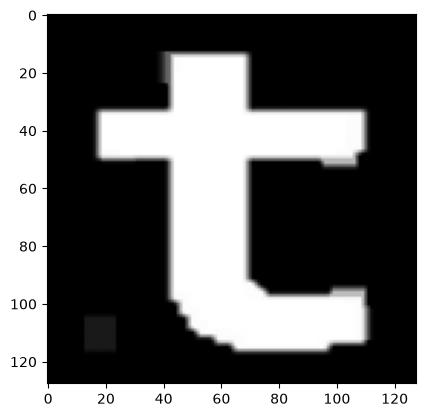

[0.04188307733392137, 0.03800827328833679, 0.03553748888977171]
1.101946331952249
Predicted label for test image: t


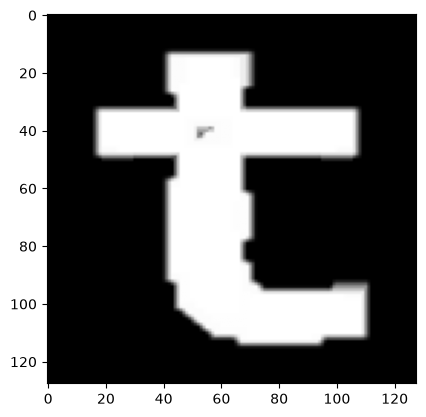

[0.0413571915421292, 0.0386840771664577, 0.03755513729006984]
1.069101154052844
Predicted label for test image: O


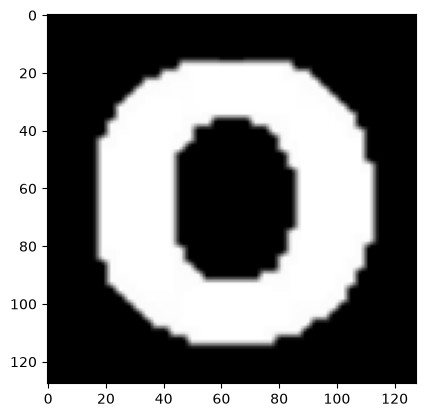

[0.041330546264225256, 0.03898790491076699, 0.03676917501407763]
1.0600863616247127
Predicted label for test image: U


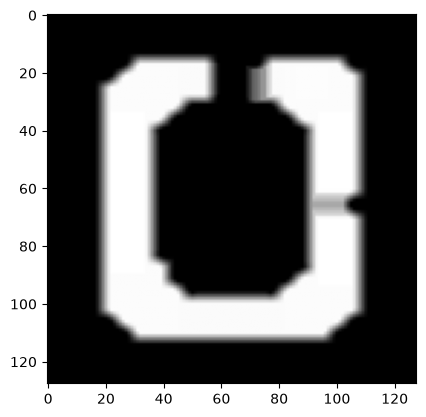

[0.03979541174965983, 0.03859819209534451, 0.03832976352604811]
1.0310175059846836
Predicted label for test image: J


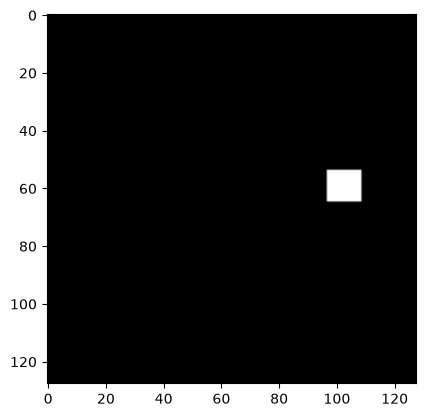

[0.04208351436011571, 0.03915062455284124, 0.03772477541530378]
1.0749129762493566
Predicted label for test image: T


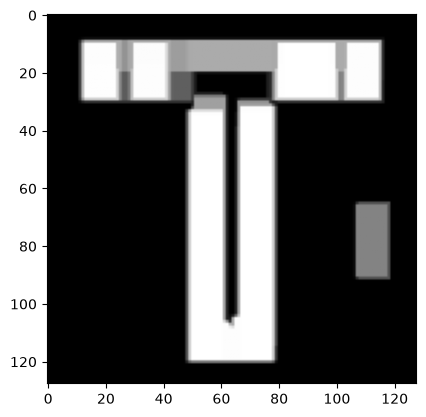

[0.04232247702223234, 0.03920152805113821, 0.03816675234806139]
1.0796129417971376
Predicted label for test image: e


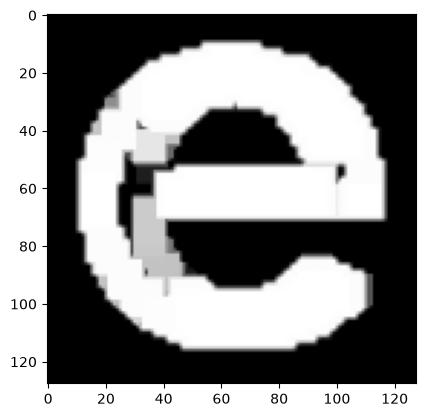

[0.03960515019157483, 0.03739536701974029, 0.03732299001615047]
1.059092431708667
Predicted label for test image: n


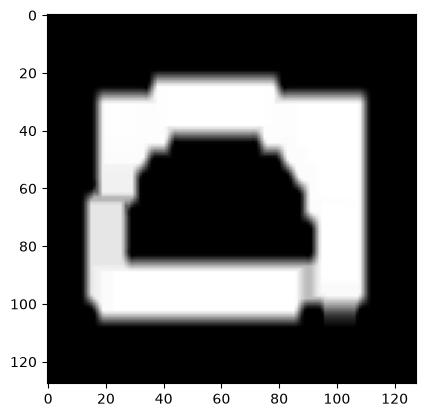

[0.039808407147442826, 0.038326968732946415, 0.035595856381116654]
1.0386526371239724
Predicted label for test image: X


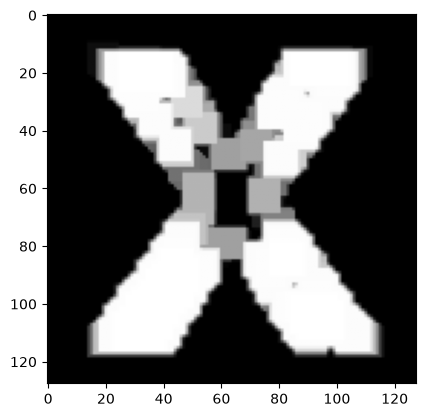

[0.04145568185409992, 0.03826086579799196, 0.036372629174881925]
1.083500882415359
Predicted label for test image: t


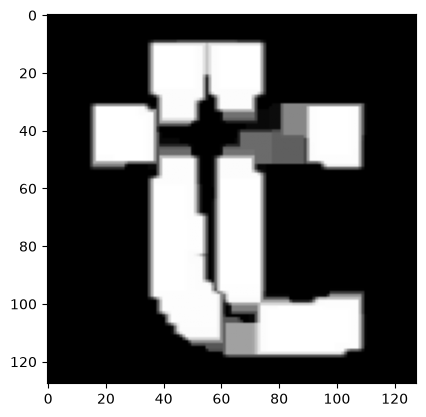

[0.039426478801006345, 0.03770262707004613, 0.03708364122332397]
1.0457223240109381
Predicted label for test image: T


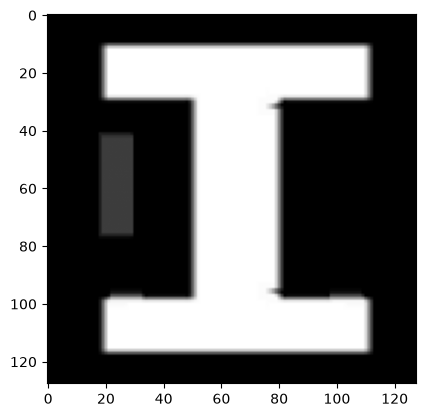

[0.04179983050773786, 0.041730396410067656, 0.038233211941923646]
1.001663873426648
Predicted label for test image: M


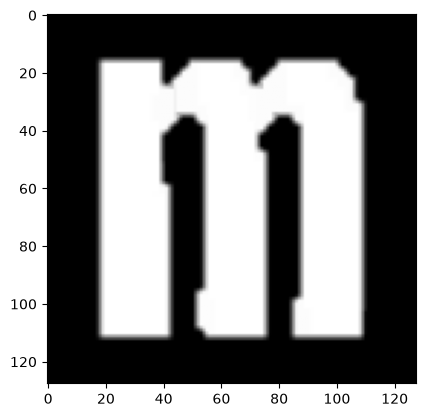

[0.04231903547968414, 0.03980649310493636, 0.03664427046091008]
1.0631189079662031
Predicted label for test image: a


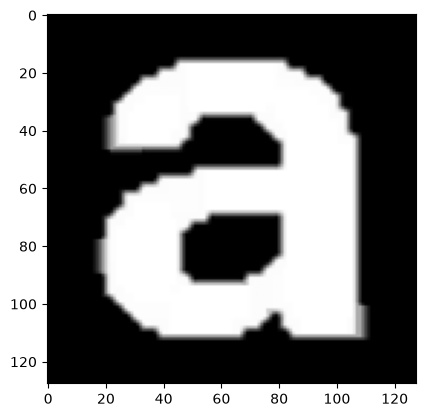

[0.039740166269297425, 0.03873582231047651, 0.037433242999981305]
1.0259280402200028
Predicted label for test image: a


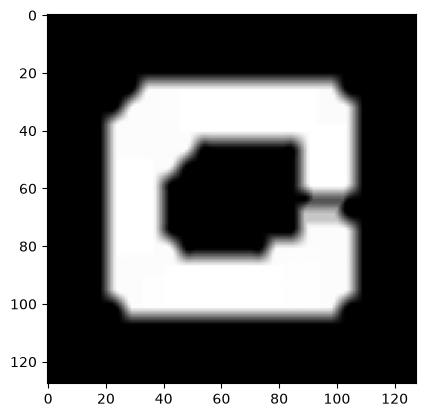

[0.04094831327095726, 0.038262593882261955, 0.03778603761954736]
1.0701917752089558
Predicted label for test image: g


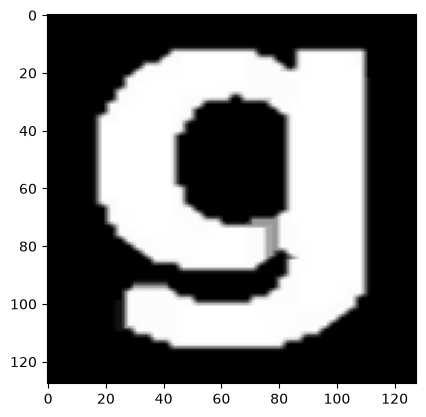

[0.04060320734475322, 0.03939578891999609, 0.03837063571735622]
1.0306484133928406
Predicted label for test image: n


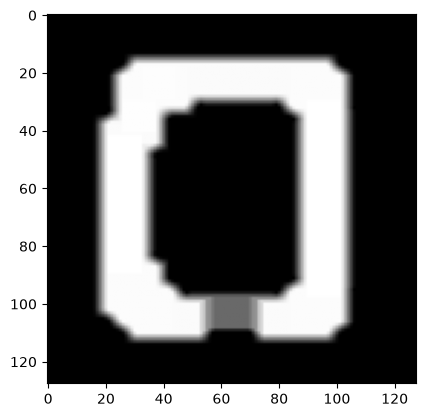

[0.04248038297275261, 0.04068645536307237, 0.039087983041082706]
1.0440915187541366
Predicted label for test image: e


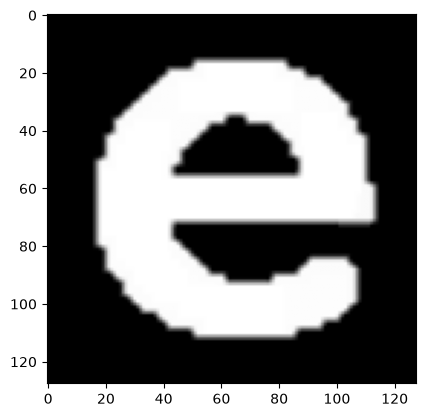

[0.040234585155282665, 0.03826421752864597, 0.03774914217138075]
1.0514937389000991
Predicted label for test image: E


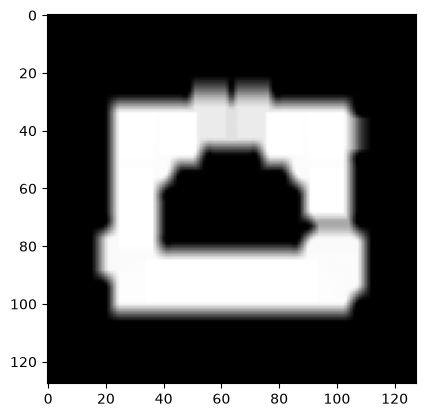

[0.04155621450435563, 0.03970005312868321, 0.03828083301497028]
1.0467546320317478
Predicted label for test image: O


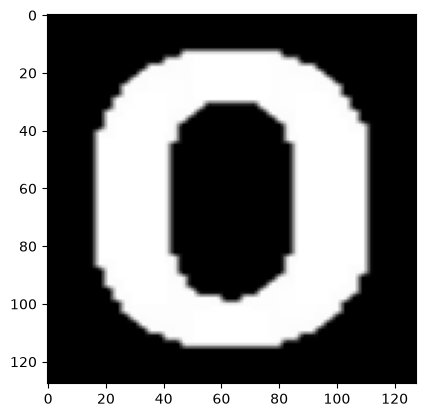

[0.04086978248997328, 0.040702530236685124, 0.03979541591288636]
1.0041091365159753
Predicted label for test image: N


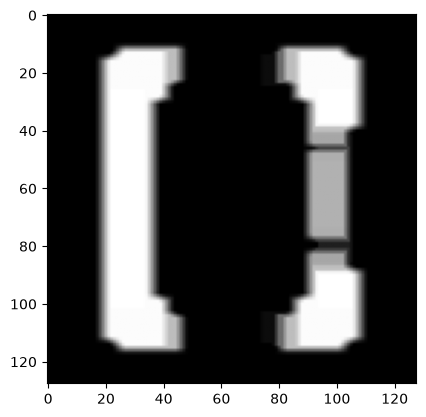

[0.04238609975556692, 0.037699880868125195, 0.03768675863803184]
1.124303281059009
Predicted label for test image: n


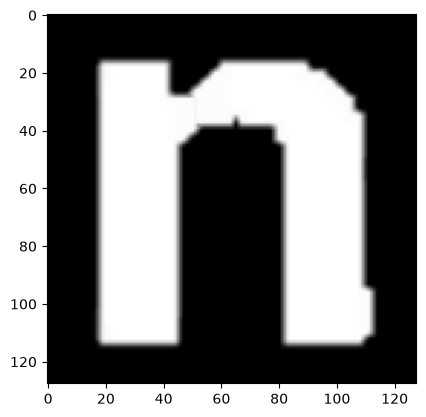

[0.040498274952450584, 0.03761434035735576, 0.03680742556034669]
1.076671146368538
Predicted label for test image: L


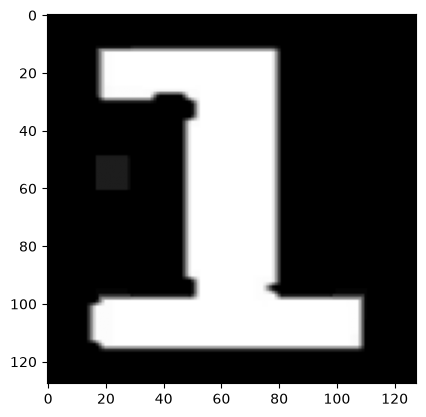

[0.039641577740917075, 0.039565951567774815, 0.03818074984569428]
1.001911395281691
Predicted label for test image: L


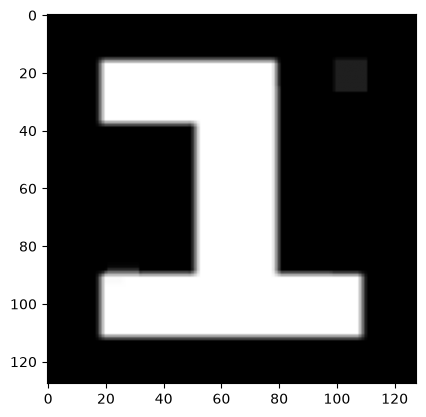

[0.03828780283009731, 0.03661298019457384, 0.035800163708496036]
1.0457439581979642
Predicted label for test image: O


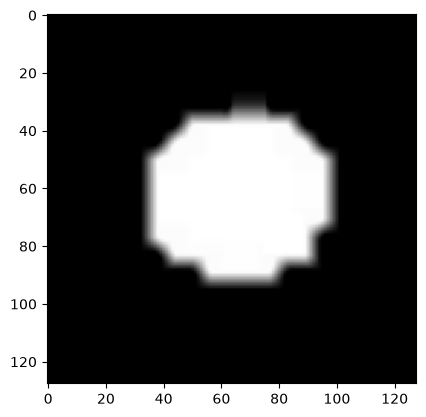

[0.042456777037242314, 0.04006290035762585, 0.03786023535877177]
1.059752954934547
Predicted label for test image: n


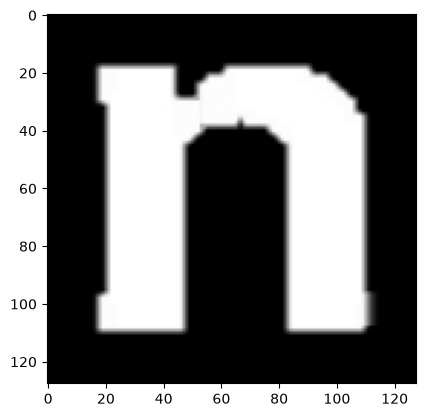

[0.04247696364045024, 0.04055602282315972, 0.0394054803999871]
1.0473651182628678
Predicted label for test image: e


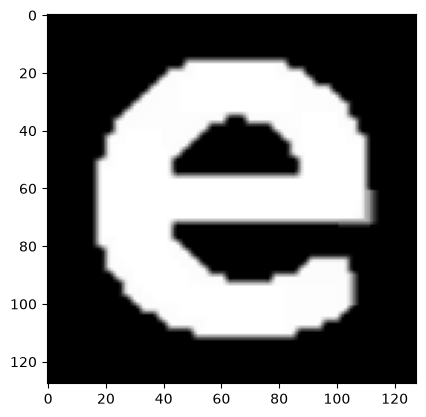

[0.04105933447439583, 0.039233061922160466, 0.03881589562578081]
1.046549325052904
Predicted label for test image: H


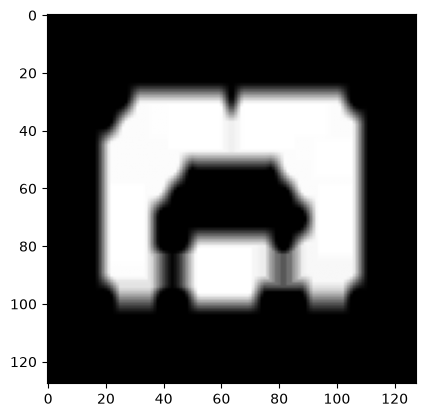

[0.041025062078077365, 0.038428669023303635, 0.037874407078505]
1.0675639599487363
Predicted label for test image: E


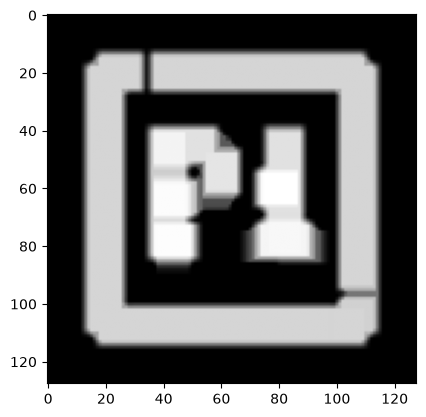

[0.039160965937218864, 0.03724700490307812, 0.03420544287631463]
1.0513856359490148
Predicted label for test image: P


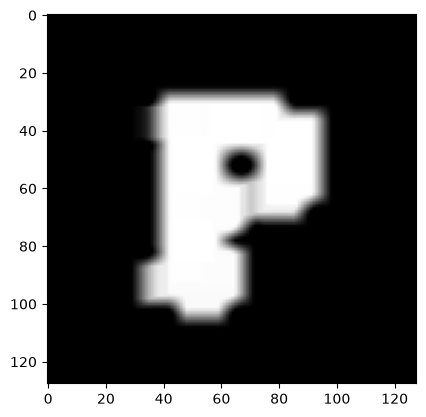

[0.04009325038801113, 0.04004307599793031, 0.037672674768049454]
1.0012530103852013
Predicted label for test image: n


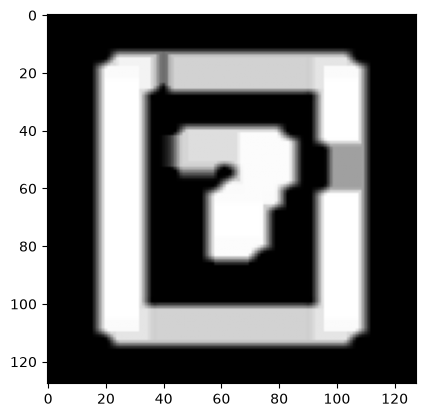

[0.03593593145642646, 0.033911975583728646, 0.032284313088192955]
1.0596826294504922
Predicted label for test image: n


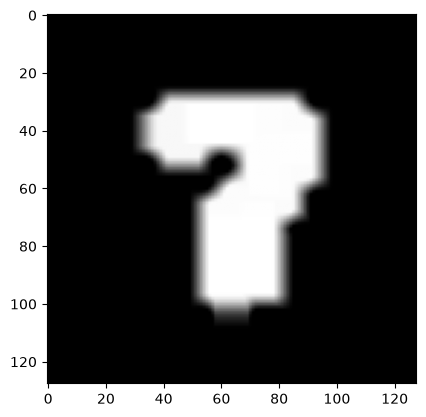

[0.040878210169726065, 0.04071340637235759, 0.03851734753630055]
1.0040478999929705
Predicted label for test image: H


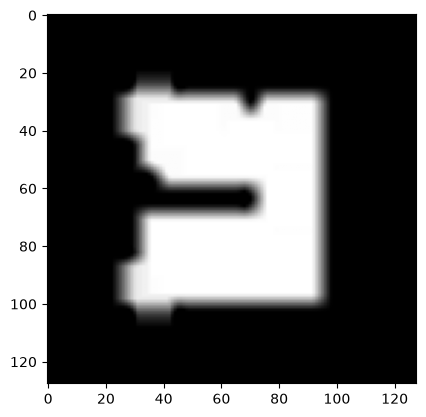

In [26]:
unique_boxes = sort_boxes_reading_order(unique_boxes, y_thresh=10)
words = merge_char_words(unique_boxes, x_thresh=20, y_thresh=30)
print(f"Number of words: {len(words)}")
text = ""
for word in words:
    for box in word:
        x, y, w, h = box
        # print(f"width: {w}, height: {h}")
        # print(f"Box {i}: x={x}, y={y}")
        char_img = gray[y:y+h, x:x+w]
        # plt.imshow(char_img, cmap='gray')
        # plt.show()
        
        ## border
        padded_char_img = cv2.copyMakeBorder(char_img, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=255)
        ## blur
        blurred_char_img = cv2.GaussianBlur(padded_char_img, (5, 5), 0)

        ## binarize
        binarized_char_img = cv2.adaptiveThreshold(
            blurred_char_img,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,
            2
        )

        
        ## resize
        resized_char_img = cv2.resize(
            binarized_char_img,
            (128, 128),
            interpolation=cv2.INTER_CUBIC
        )

        ## erode and dilate
        eroded = cv2.erode(resized_char_img, np.ones((5, 5), np.uint8), iterations=2)
        dilated = cv2.dilate(eroded, np.ones((3, 3), np.uint8), iterations=5)

        ## normalized
        normalized_char_img = dilated.astype(np.float32) / 255.0

        magnitudes, orientations = calc_gradients(normalized_char_img)
        features = HoG(orientations, magnitudes)
        # predicted_label, scores = predict(features)
        # char_non_char_pred = char_non_char_model.predict(features.reshape(1, -1))
        # if char_non_char_pred == 0:
        #     print("Non-character detected, skipping...")
        #     continue
        # print(f"char_non_char_pred: {char_non_char_pred}")
        predicted_label, confidence = predict_char(features, model, le)
        props = model.predict_proba(features.reshape(1, -1))
        top3 = sorted(props[0], reverse=True)[:3]
        print(top3)
        print(top3[0]/top3[1])
        print("Predicted label for test image:", le.inverse_transform(predicted_label)[0])
        plt.imshow(normalized_char_img, cmap='gray')
        plt.show()
        text += le.inverse_transform(predicted_label)[0]
        text += " "
    # text += " "

In [27]:
toLower = text.lower()
print(toLower)

a m m p n d n h d u a u d u d u t e a x t t o u j t e n x t t m a a g n e e o n n l l o n e h e p n n h 
